In [5]:
!pip install numpy opencv-python matplotlib

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from IPython.display import display, clear_output
from tqdm.notebook import tqdm
from datetime import datetime, timedelta

In [2]:
# --- Settings --- 
video_path = '20241023_TrepS_01_in (2).MOV'
resize_rate = 0.2
sample_rate = 29
start_frame = 45000
start_time = datetime.strptime("23.10.2024 07:01:31", "%d.%m.%Y %H:%M:%S")

In [7]:
# --- Open video ---
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Error: Could not open video.")
    cap.release()
    raise FileNotFoundError(f"Failed to load video: {video_path}")

fps = int(cap.get(cv2.CAP_PROP_FPS))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Frames per Second: {fps}")
print(f"Total Frames: {total_frames}")
print(f"Starttime: {start_time}")
print(f"calculated Endtime: {start_time + timedelta(seconds=(total_frames/fps))}")

Frames per Second: 29
Total Frames: 66411
Starttime: 2024-10-23 07:01:31
calculated Endtime: 2024-10-23 07:39:41.034483


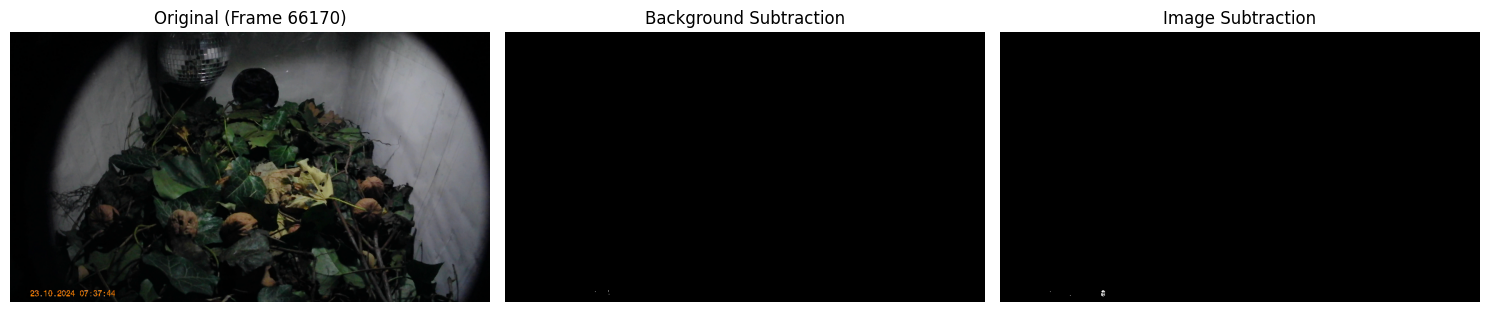

Starting video analysis...


Processing Frames:   0%|          | 0/739 [00:00<?, ?it/s]

In [8]:
backSub = cv2.createBackgroundSubtractorMOG2(history=400, varThreshold=50, detectShadows=True)

motion_bg_percent = []   # Background Subtraction
motion_img_percent = []  # Image Subtraction
saved_count = 0
frame_idx = 0
prev_gray = None
timestamps = []

display_handle = display(None, display_id=True)

print("Starting video analysis...")
for i in tqdm(range(start_frame, total_frames, sample_rate), desc="Processing Frames",leave=True):
    cap.set(cv2.CAP_PROP_POS_FRAMES, i)
    ret, frame = cap.read()
    if not ret:
        break
        
    frame_time = start_time + timedelta(seconds=i / fps)
    timestamps.append(frame_time)
    
    #resize frame
    frame = cv2.resize(frame, (0, 0), fx=resize_rate, fy=resize_rate)
        
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    total_pixels = frame_gray.size
    
    #background substraction
    fg_mask = backSub.apply(frame)
    count_bg = np.sum(fg_mask > 0)
    percent_bg = (count_bg / total_pixels) * 100
    motion_bg_percent.append(percent_bg)
    
    # Image Subtraction
    if prev_gray is not None:
        diff = cv2.absdiff(frame_gray, prev_gray)
        _, diff_thresh = cv2.threshold(diff, 30, 255, cv2.THRESH_BINARY)
        count_img = np.sum(diff_thresh > 0)
    else:
        diff_thresh = np.zeros_like(frame_gray)  # ← Fix: Leeres Bild beim ersten Frame
        count_img = 0

    percent_img = (count_img / total_pixels) * 100
    motion_img_percent.append(percent_img)
    prev_gray = frame_gray.copy()
    
    if i % 10 == 0:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Original (Frame {i})")
        axes[0].axis('off')

        axes[1].imshow(fg_mask, cmap='gray')
        axes[1].set_title("Background Subtraction")
        axes[1].axis('off')

        if prev_gray is not None:
            axes[2].imshow(diff_thresh, cmap='gray')
            axes[2].set_title("Image Subtraction")
            axes[2].axis('off')

        plt.tight_layout()
        display_handle.update(fig)
        plt.close(fig)

    frame_idx += 1
    
cap.release()

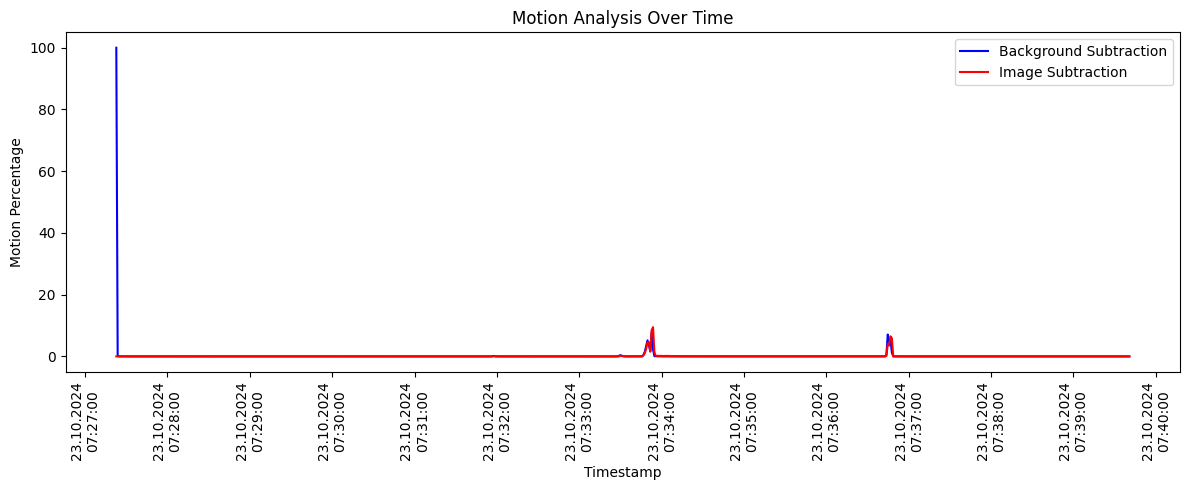

In [11]:
# Example: plotting background subtraction motion
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(timestamps, motion_bg_percent, label="Background Subtraction", color="blue")
ax.plot(timestamps, motion_img_percent, label="Image Subtraction", color="red")

# Format x-axis as datetime
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d.%m.%Y\n%H:%M:%S'))  # show hours:minutes:seconds
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=10, maxticks=50))             # auto-adjust tick locations

plt.xlabel("Timestamp")
plt.ylabel("Motion Percentage")
plt.title("Motion Analysis Over Time")
plt.legend()
plt.xticks(rotation=90)  # rotate timestamps for readability
plt.tight_layout()
plt.show()


In [12]:
motion_threshold = 1
motion_active = False
start_time = None

for t, motion in zip(timestamps, motion_img_percent):
    if motion > motion_threshold and not motion_active:
        # Motion started
        start_time = t
        motion_active = True
    elif motion <= motion_threshold and motion_active:
        # Motion ended
        end_time = t
        motion_active = False
        print(f"There was motion in the box between {start_time.strftime('%H:%M:%S')} and {end_time.strftime('%H:%M:%S')}")


There was motion in the box between 07:33:47 and 07:33:55
There was motion in the box between 07:36:44 and 07:36:48
